# Metrics Development

## Setup

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import umap
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from pathlib import Path

data_path = "../outputs/%s/embeddings/"


## Single-run exploration

In [4]:
test_proj = np.load(data_path % 'run_test_local_20260330_1745' + "test_projections.npy")                                         
test_labels = np.load(data_path % 'run_test_local_20260330_1745' + "test_labels.npy")  

print("test_proj shape:", test_proj.shape)
print("test_labels shape:", test_labels.shape)

test_proj shape: (30, 256)
test_labels shape: (30, 20)


In [5]:
# Mask for FRI only, FRII only, and hybrid
mask_fri = (test_labels[:,0] == 1) & (test_labels[:,1] == 0) & (test_labels[:,2] == 0)
mask_frii = (test_labels[:,0] == 0) & (test_labels[:,1] == 1) & (test_labels[:,2] == 0)
mask_hybrid = test_labels[:, 2] == 1 #OK

# Combine them
combined_mask = mask_fri | mask_frii | mask_hybrid
print(mask_fri.shape, combined_mask.shape)

(30,) (30,)


In [6]:
#the labels are in the format of a one-hot encoding, so we need to convert them to a single label for each class
test_labels_single = np.argmax(test_labels[combined_mask], axis=1)

silhouette = silhouette_score(test_proj[combined_mask], test_labels_single)
print("Silhouette Score:", silhouette)

davies_bouldin = davies_bouldin_score(test_proj[combined_mask], test_labels_single)
print("Davies-Bouldin Score:", davies_bouldin)

calinski_harabasz = calinski_harabasz_score(test_proj[combined_mask], test_labels_single)
print("Calinski-Harabasz Score:", calinski_harabasz)

Silhouette Score: -0.022369105368852615
Davies-Bouldin Score: 5.059326874073172
Calinski-Harabasz Score: 0.7878036494897426


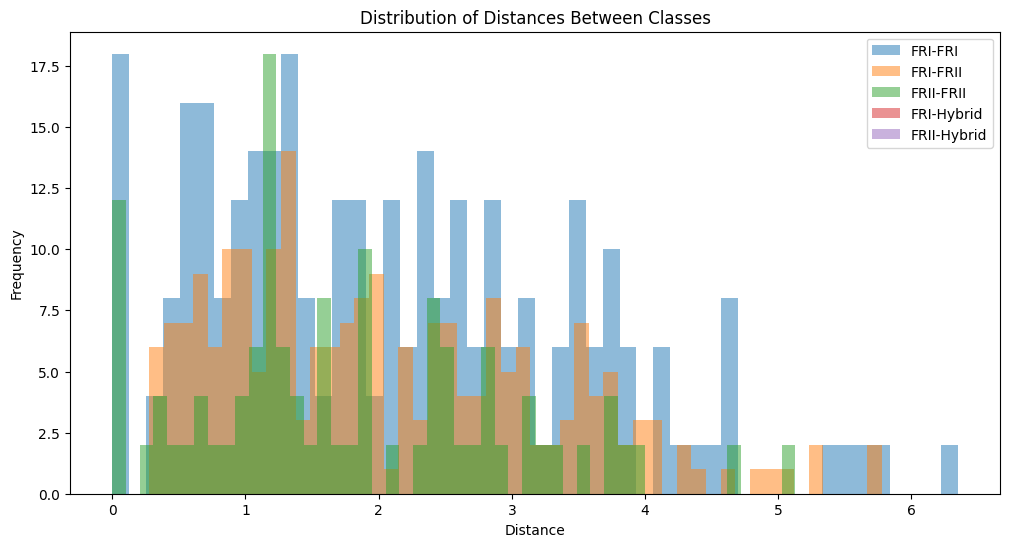

In [7]:
#Show the distribution of distance between FRI-FRII pairs, FRI-hybrid pairs, and FRII-hybrid pairs
from scipy.spatial.distance import pdist, squareform
# Compute pairwise distances
distances = squareform(pdist(test_proj[combined_mask]))
# Get indices for each class
indices_fri = np.where(test_labels_single == 0)[0]
indices_frii = np.where(test_labels_single == 1)[0]
indices_hybrid = np.where(test_labels_single == 2)[0]
# Compute distances for each pair type
dist_fri_fri = distances[np.ix_(indices_fri, indices_fri)].flatten()
dist_fri_frii = distances[np.ix_(indices_fri, indices_frii)].flatten()
dist_frii_frii = distances[np.ix_(indices_frii, indices_frii)].flatten()
dist_fri_hybrid = distances[np.ix_(indices_fri, indices_hybrid)].flatten()
dist_frii_hybrid = distances[np.ix_(indices_frii, indices_hybrid)].flatten()
# Plot histograms
plt.figure(figsize=(12, 6))
plt.hist(dist_fri_fri, bins=50, alpha=0.5, label='FRI-FRI')
plt.hist(dist_fri_frii, bins=50, alpha=0.5, label='FRI-FRII')
plt.hist(dist_frii_frii, bins=50, alpha=0.5, label='FRII-FRII')
plt.hist(dist_fri_hybrid, bins=50, alpha=0.5, label='FRI-Hybrid')
plt.hist(dist_frii_hybrid, bins=50, alpha=0.5, label='FRII-Hybrid')
plt.xlabel('Distance')
plt.ylabel('Frequency')
plt.title('Distribution of Distances Between Classes')
plt.legend()
plt.show()


In [ ]:
print(np.where(combined_mask_train)[0])
print(combined_mask_train)

[   0    1    2 ... 5309 5310 5311]
[ True  True  True ...  True  True  True]


## UMAP visualisation

In [ ]:
# =============================================================================
# Interactive UMAP viewer
# -----------------------------------------------------------------------------
# splits        : list of splits to show — any subset of ['train', 'val', 'test']
# use_train_umap: if True, fit UMAP on train and *transform* val/test into the
#                 same space (comparable axes); if False, fit each split independently
# run_name      : folder name inside outputs/
# n_neighbors, min_dist : UMAP hyperparameters
# =============================================================================

splits         = ['train', 'test']   # e.g. ['train'], ['val', 'test'], ['train', 'val', 'test']
use_train_umap = True
run_name       = "run_baseline_both_w10_full_20260401_0950"
n_neighbors    = 30
min_dist       = 0.1

# -----------------------------------------------------------------------------
embed_dir = Path("../outputs") / run_name / "embeddings"

split_files = {
    'train': ('train_projections.npy', 'train_labels.npy'),
    'val':   ('val_projections.npy',   'val_labels.npy'),
    'test':  ('test_projections.npy',  'test_labels.npy'),
}

def pure_mask(labels):
    """Boolean mask for FRI-only, FRII-only, and Hybrid rows."""
    fri    = (labels[:, 0] == 1) & (labels[:, 1] == 0) & (labels[:, 2] == 0)
    frii   = (labels[:, 0] == 0) & (labels[:, 1] == 1) & (labels[:, 2] == 0)
    hybrid =  labels[:, 2] == 1
    return fri | frii | hybrid

# Load requested splits
data = {}
for s in splits:
    proj_file, lbl_file = split_files[s]
    proj   = np.load(embed_dir / proj_file)
    labels = np.load(embed_dir / lbl_file)
    mask   = pure_mask(labels)
    data[s] = {'proj': proj, 'labels': labels, 'mask': mask}

# Fit UMAP
if use_train_umap:
    if 'train' not in data:
        raise ValueError("use_train_umap=True requires 'train' in splits")
    train_proj_masked = data['train']['proj'][data['train']['mask']]
    reducer = umap.UMAP(n_neighbors=n_neighbors, min_dist=min_dist,
                        metric='euclidean', random_state=42)
    data['train']['embedding'] = reducer.fit_transform(train_proj_masked)
    for s in splits:
        if s == 'train':
            continue
        data[s]['embedding'] = reducer.transform(data[s]['proj'][data[s]['mask']])
else:
    for s in splits:
        data[s]['embedding'] = UMAP_embedding(
            data[s]['proj'][data[s]['mask']], n_neighbors=n_neighbors, min_dist=min_dist
        )

# Plot
fig, axes = plt.subplots(1, len(splits), figsize=(5 * len(splits), 4), squeeze=False)
axes = axes[0]

colors = {'FRI': 'red', 'FRII': 'blue', 'Hybrid': 'green'}
umap_label = "train UMAP space" if use_train_umap else "independent UMAP"

for ax, s in zip(axes, splits):
    emb    = data[s]['embedding']
    labels = data[s]['labels'][data[s]['mask']]
    ax.scatter(emb[labels[:, 0] == 1, 0], emb[labels[:, 0] == 1, 1],
               c=colors['FRI'],    s=2, alpha=0.7, label='FRI')
    ax.scatter(emb[labels[:, 1] == 1, 0], emb[labels[:, 1] == 1, 1],
               c=colors['FRII'],   s=2, alpha=0.7, label='FRII')
    ax.scatter(emb[labels[:, 2] == 1, 0], emb[labels[:, 2] == 1, 1],
               c=colors['Hybrid'], s=2, alpha=0.7, label='Hybrid')
    ax.set_title(f"{s}  [{umap_label}]")
    ax.legend(markerscale=4, fontsize=8)
    ax.set_xlabel("UMAP 1")
    ax.set_ylabel("UMAP 2")

fig.suptitle(run_name, fontsize=10)
plt.tight_layout()
plt.show()


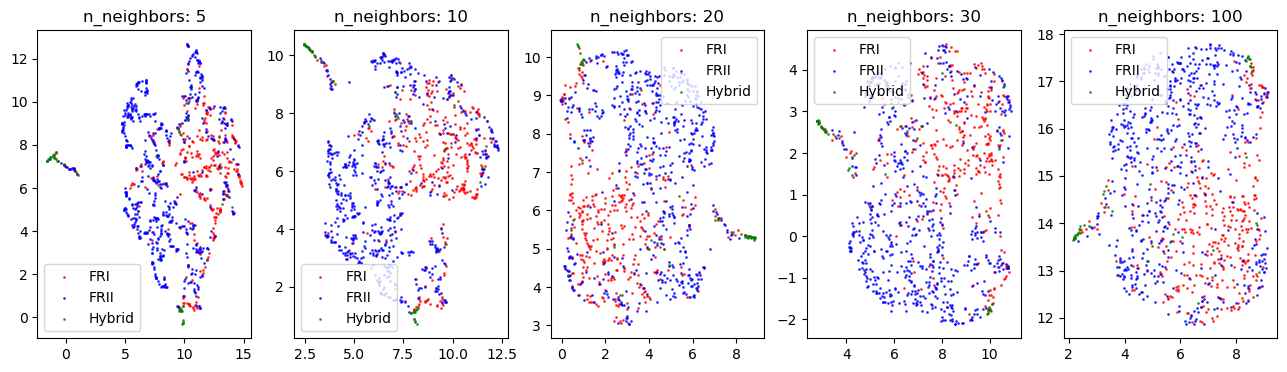

In [ ]:
#test umap-learn by varying the n_neighbors and min_dist parameters

def UMAP_embedding(embeddings, n_neighbors=15, min_dist=0.1):
    reducer = umap.UMAP(
        n_neighbors=n_neighbors,
        min_dist=min_dist,
        metric='euclidean'
    )
    embedding_2d = reducer.fit_transform(embeddings)
    return embedding_2d

# Make 5 subplots varying n_neighbors

n_neighbors_values = [5, 10, 20, 30, 100]

plt.figure(figsize=(16, 4))
for i, n_neighbors in enumerate(n_neighbors_values):
    embedding_2d = UMAP_embedding(test_proj[combined_mask], n_neighbors=n_neighbors, min_dist=0.1)
    plt.subplot(1, 5, i + 1)
    scatter = plt.scatter(embedding_2d[test_labels_single == 0, 0], embedding_2d[test_labels_single == 0, 1], c='red', label='FRI', alpha=0.7, s=1)
    scatter = plt.scatter(embedding_2d[test_labels_single == 1, 0], embedding_2d[test_labels_single == 1, 1], c='blue', label='FRII', alpha=0.7, s=1)
    scatter = plt.scatter(embedding_2d[test_labels_single == 2, 0], embedding_2d[test_labels_single == 2, 1], c='green', label='Hybrid', alpha=0.7, s=1)
    plt.legend()
    plt.title(f'n_neighbors: {n_neighbors}')
plt.show()

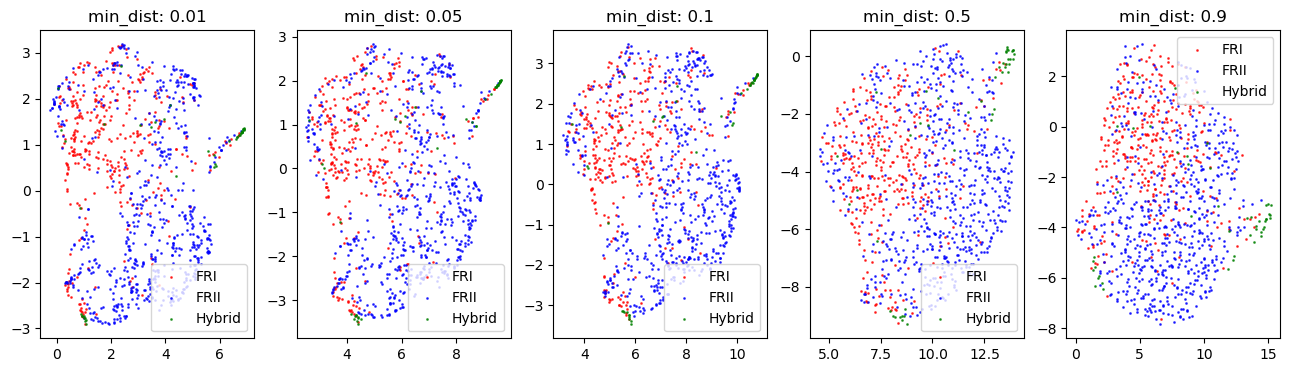

In [ ]:
# Make 5 subplots varying min_dist
min_dist_values = [0.01, 0.05, 0.1, 0.5, 0.9]
plt.figure(figsize=(16, 4))
for i, min_dist in enumerate(min_dist_values):
    embedding_2d = UMAP_embedding(test_proj[combined_mask], n_neighbors=50, min_dist=min_dist)
    plt.subplot(1, 5, i + 1)
    scatter = plt.scatter(embedding_2d[test_labels_single == 0, 0], embedding_2d[test_labels_single == 0, 1], c='red', label='FRI', alpha=0.7, s=1)
    scatter = plt.scatter(embedding_2d[test_labels_single == 1, 0], embedding_2d[test_labels_single == 1, 1], c='blue', label='FRII', alpha=0.7, s=1)
    scatter = plt.scatter(embedding_2d[test_labels_single == 2, 0], embedding_2d[test_labels_single == 2, 1], c='green', label='Hybrid', alpha=0.7, s=1)
    plt.legend()
    plt.title(f'min_dist: {min_dist}')
plt.show()

(1142,) (5312,)


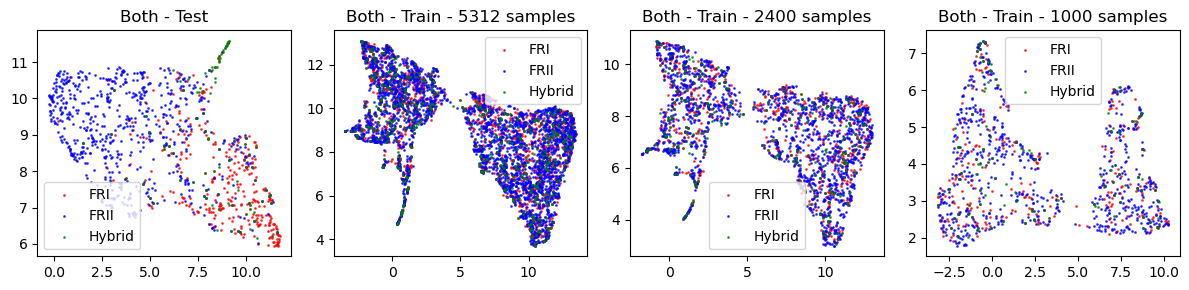

In [ ]:
# Now let's do the UMAPs for the best cases of both and either. We take n_neighbors=30 and min_dist=0.1.
# We do on the train and on the test. We vary the number of samples on train from all to the same number as test.
n_neighbors = 30
min_dist = 0.1
#First for both, best is with w=10
test_proj_both = np.load(data_path%f"run_both_w10" + "test_projections.npy")
test_labels_both = np.load(data_path%f"run_both_w10" + "test_labels.npy")
train_proj_both = np.load(data_path%f"run_both_w10" + "train_projections.npy")
train_labels_both = np.load(data_path%f"run_both_w10" + "train_labels.npy")
#compute the combined mask for train and test
mask_fri_test = (test_labels_both[:,0] == 1) & (test_labels_both[:,1] == 0) & (test_labels_both[:,2] == 0)
mask_frii_test = (test_labels_both[:,0] == 0 ) & (test_labels_both[:,1] == 1) & (test_labels_both[:,2] == 0)
mask_hybrid_test = test_labels_both[:, 2] == 1 #OK
mask_fri_train = (train_labels_both[:,0] == 1) & (train_labels_both[:,1] == 0) & (train_labels_both[:,2] == 0)
mask_frii_train = (train_labels_both[:,0] == 0) & (train_labels_both[:,1] == 1) & (train_labels_both[:,2] == 0)
mask_hybrid_train = train_labels_both[:, 2] == 1 #OK
combined_mask_test = mask_fri_test | mask_frii_test | mask_hybrid_test
combined_mask_train = mask_fri_train | mask_frii_train | mask_hybrid_train
print(combined_mask_test.shape, combined_mask_train.shape)
#run Umap on test and train
embedding_2d_test_both = UMAP_embedding(test_proj_both[combined_mask_test], n_neighbors=n_neighbors, min_dist=min_dist)
embedding_2d_train_both = UMAP_embedding(train_proj_both[combined_mask_train], n_neighbors=n_neighbors, min_dist=min_dist)
#plot
plt.figure(figsize=(12, 3))
plt.subplot(1, 4, 1)
scatter = plt.scatter(embedding_2d_test_both[test_labels_both[combined_mask_test][:,0] == 1, 0], embedding_2d_test_both[test_labels_both[combined_mask_test][:,0] == 1, 1], c='red', label='FRI', alpha=0.7, s=1)
scatter = plt.scatter(embedding_2d_test_both[test_labels_both[combined_mask_test][:,1] == 1, 0], embedding_2d_test_both[test_labels_both[combined_mask_test][:,1] == 1, 1], c='blue', label='FRII', alpha=0.7, s=1)
scatter = plt.scatter(embedding_2d_test_both[test_labels_both[combined_mask_test][:,2] == 1, 0], embedding_2d_test_both[test_labels_both[combined_mask_test][:,2] == 1, 1], c='green', label='Hybrid', alpha=0.7, s=1)
plt.legend()
plt.title(f'Both - Test')
# Now do it for train, full sample, 2400 random samples and 1200 random samples
for i, n_samples in enumerate([combined_mask_train.shape[0], 2400, 1000]):
    if n_samples < combined_mask_train.shape[0]:
        indices = np.random.choice(np.where(combined_mask_train)[0], size=n_samples, replace=False)
    else:
        indices = np.where(combined_mask_train)[0]
    embedding_2d_train_both_sample = UMAP_embedding(train_proj_both[indices], n_neighbors=n_neighbors, min_dist=min_dist)
    plt.subplot(1, 4, i + 2)
    scatter = plt.scatter(embedding_2d_train_both_sample[train_labels_both[indices][:,0] == 1, 0], embedding_2d_train_both_sample[train_labels_both[indices][:,0] == 1, 1], c='red', label='FRI', alpha=0.7, s=1)
    scatter = plt.scatter(embedding_2d_train_both_sample[train_labels_both[indices][:,1] == 1, 0], embedding_2d_train_both_sample[train_labels_both[indices][:,1] == 1, 1], c='blue', label='FRII', alpha=0.7, s=1)
    scatter = plt.scatter(embedding_2d_train_both_sample[train_labels_both[indices][:,2] == 1, 0], embedding_2d_train_both_sample[train_labels_both[indices][:,2] == 1, 1], c='green', label='Hybrid', alpha=0.7, s=1)
    plt.legend()
    plt.title(f'Both - Train - {n_samples} samples')
plt.tight_layout()
plt.show()

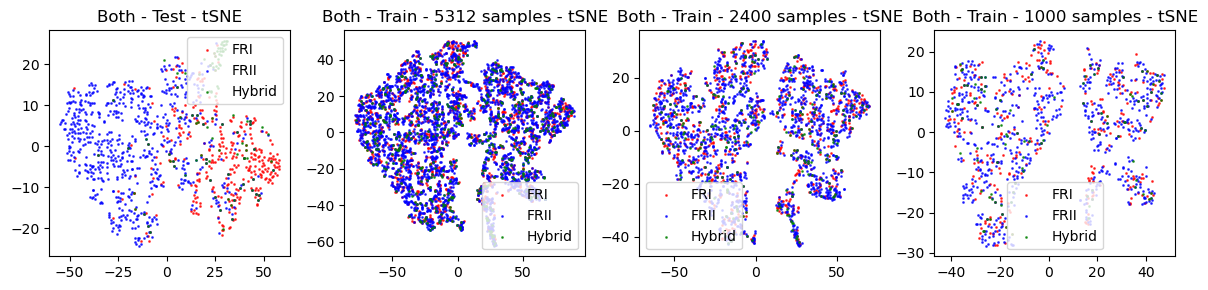

In [ ]:
#try tSNE on the same data: sklearn.manifold.TSNE
from sklearn.manifold import TSNE
embedding_2d_test_both_tsne = TSNE(n_components=2, perplexity=30).fit_transform(test_proj_both[combined_mask_test])
embedding_2d_train_both_tsne = TSNE(n_components=2, perplexity=30).fit_transform(train_proj_both[combined_mask_train])
#plot
plt.figure(figsize=(12, 3))
plt.subplot(1, 4, 1)
scatter = plt.scatter(embedding_2d_test_both_tsne[test_labels_both[combined_mask_test][:,0] == 1, 0], embedding_2d_test_both_tsne[test_labels_both[combined_mask_test][:,0] == 1, 1], c='red', label='FRI', alpha=0.7, s=1)
scatter = plt.scatter(embedding_2d_test_both_tsne[test_labels_both[combined_mask_test][:,1] == 1, 0], embedding_2d_test_both_tsne[test_labels_both[combined_mask_test][:,1] == 1, 1], c='blue', label='FRII', alpha=0.7, s=1)
scatter = plt.scatter(embedding_2d_test_both_tsne[test_labels_both[combined_mask_test][:,2] == 1, 0], embedding_2d_test_both_tsne[test_labels_both[combined_mask_test][:,2] == 1, 1], c='green', label='Hybrid', alpha=0.7, s=1)
plt.legend()
plt.title(f'Both - Test - tSNE')
# Now do it for train, full sample, 2400 random samples and 1200 random samples
for i, n_samples in enumerate([combined_mask_train.shape[0], 2400, 1000]):
    if n_samples < combined_mask_train.shape[0]:
        indices = np.random.choice(np.where(combined_mask_train)[0], size=n_samples, replace=False)
    else:
        indices = np.where(combined_mask_train)[0]
    embedding_2d_train_both_sample_tsne = TSNE(n_components=2, perplexity=30).fit_transform(train_proj_both[indices])
    plt.subplot(1, 4, i + 2)
    scatter = plt.scatter(embedding_2d_train_both_sample_tsne[train_labels_both[indices][:,0] == 1, 0], embedding_2d_train_both_sample_tsne[train_labels_both[indices][:,0] == 1, 1], c='red', label='FRI', alpha=0.7, s=1)
    scatter = plt.scatter(embedding_2d_train_both_sample_tsne[train_labels_both[indices][:,1] == 1, 0], embedding_2d_train_both_sample_tsne[train_labels_both[indices][:,1] == 1, 1], c='blue', label='FRII', alpha=0.7, s=1)
    scatter = plt.scatter(embedding_2d_train_both_sample_tsne[train_labels_both[indices][:,2] == 1, 0], embedding_2d_train_both_sample_tsne[train_labels_both[indices][:,2] == 1, 1], c='green', label='Hybrid', alpha=0.7, s=1)
    #plt.legend()
    plt.title(f'Both - Train - {n_samples} samples - tSNE')
plt.tight_layout()
plt.show()

## Nearest-neighbour & distance analysis

In [ ]:
# =============================================================================
# KNN Nearest-Neighbour Gallery
# =============================================================================
# Config — edit these
run_name = "run_baseline_both_w10_full_20260401_0950"
split    = 'test'   # 'train', 'val', 'test'
N        = 5        # number of classes to sample
seed     = 42       # must match the seed used when creating embeddings
# =============================================================================

import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.neighbors import NearestNeighbors

ALL_CLASS_NAMES = [
    'FRI', 'FRII', 'Hybrids', 'Spirals', 'Relaxed doubles',
    'C-curv', 'S-curv', 'Misalign', 'Wings', 'X-shaped',
    'Straight jets', 'Multi hotspots', 'Cont. jets', 'Banding', 'One-sided', 'Restarted',
    'Cluster', 'Merger', 'Diffuse', 'Unknown',
]

# --- Load data ---
images_full = np.load('data/images.npy')          # (7607, 89, 89)

all_idx = np.arange(len(images_full))
train_idx, temp_idx = train_test_split(all_idx, test_size=0.30, random_state=seed)
val_idx,  test_idx  = train_test_split(temp_idx, test_size=0.5,  random_state=seed)
split_idx = {'train': train_idx, 'val': val_idx, 'test': test_idx}[split]
images = images_full[split_idx]

emb_dir  = f'outputs/{run_name}/embeddings/'
projections = np.load(emb_dir + f'{split}_projections.npy')   # (N_split, 256)
labels      = np.load(emb_dir + f'{split}_labels.npy')        # (N_split, 20)

# --- Sample N classes ---
rng = np.random.default_rng(seed)
positive_counts = (labels == 1).sum(axis=0)          # (20,)
valid_cols = np.where(positive_counts >= 1)[0]
sampled_cols = rng.choice(valid_cols, size=N, replace=False)

# --- Fit KNN once ---
nn_model = NearestNeighbors(n_neighbors=9, metric='euclidean').fit(projections)

# --- Plot ---
fig, axes = plt.subplots(N * 3, 3, figsize=(9, N * 9 + 1))

for i, col in enumerate(sampled_cols):
    anchor_idx = int(rng.choice(np.where(labels[:, col] == 1)[0]))
    _, indices = nn_model.kneighbors(projections[anchor_idx:anchor_idx + 1])
    nn_idxs = indices[0][1:]   # 8 neighbours, skip self

    # Grid layout: [nn0 nn1 nn2 / nn3 ANCHOR nn4 / nn5 nn6 nn7]
    grid_idxs = [nn_idxs[0], nn_idxs[1], nn_idxs[2],
                 nn_idxs[3], anchor_idx,  nn_idxs[4],
                 nn_idxs[5], nn_idxs[6],  nn_idxs[7]]

    for flat_pos, data_idx in enumerate(grid_idxs):
        row = i * 3 + flat_pos // 3
        col_pos = flat_pos % 3
        ax = axes[row, col_pos]

        ax.imshow(images[data_idx], cmap='gray', origin='lower')
        ax.axis('off')

        # Golden border on anchor
        if data_idx == anchor_idx:
            for spine in ax.spines.values():
                spine.set_visible(True)
                spine.set_edgecolor('gold')
                spine.set_linewidth(3)
            ax.axis('on')
            ax.set_xticks([])
            ax.set_yticks([])

        # Label text overlay
        lbl = labels[data_idx]
        active = [ALL_CLASS_NAMES[j] for j in range(20) if lbl[j] == 1]
        tag = ', '.join(active) if active else '—'
        ax.text(0.02, 0.02, tag, transform=ax.transAxes, fontsize=4.5,
                color='white', va='bottom', ha='left', wrap=True,
                bbox=dict(facecolor='black', alpha=0.5, pad=1, linewidth=0))

        # Row title on middle-left subplot of each 3×3 block
        if flat_pos == 3:   # left cell of middle row
            ax.set_ylabel(f"Class: {ALL_CLASS_NAMES[col]}", fontsize=9, labelpad=4)

fig.suptitle(f'{run_name}  |  {split} split  |  KNN gallery', fontsize=10)
plt.tight_layout()
plt.show()


In [ ]:
# =============================================================================
# Cosine distance (embedding) vs Hamming distance (labels)
# =============================================================================
run_name  = "run_baseline_both_w10_full_20260401_0950"
split     = 'test'
MAX_PAIRS = 300_000
seed      = 42
# =============================================================================

from scipy.spatial.distance import pdist
from scipy.stats import spearmanr
import numpy as np, matplotlib.pyplot as plt
from pathlib import Path

emb_dir = Path(f'../outputs/{run_name}/embeddings')
proj    = np.load(emb_dir / f'{split}_projections.npy')
labels  = np.load(emb_dir / f'{split}_labels.npy')

cos_d  = pdist(proj,   metric='cosine')
ham_d  = (pdist(labels, metric='hamming') * labels.shape[1]).round().astype(int)

rho, pval = spearmanr(cos_d, ham_d)

rng = np.random.default_rng(seed)
idx = rng.choice(len(cos_d), size=min(MAX_PAIRS, len(cos_d)), replace=False)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Hexbin
hb = axes[0].hexbin(cos_d[idx], ham_d[idx], gridsize=60, cmap='viridis', mincnt=1)
fig.colorbar(hb, ax=axes[0], label='pair count')
axes[0].set_xlabel('Cosine distance (embedding)')
axes[0].set_ylabel('Hamming distance (labels)')
axes[0].set_title(f'Cosine vs Hamming  |  Spearman ρ = {rho:.3f}  (p={pval:.2e})')

# Violin per Hamming bin
unique_h = sorted(np.unique(ham_d))
data_by_h = [cos_d[ham_d == h] for h in unique_h]
vp = axes[1].violinplot(data_by_h, positions=unique_h, showmedians=True, showextrema=False)
axes[1].set_xlabel('Hamming distance (labels)')
axes[1].set_ylabel('Cosine distance (embedding)')
axes[1].set_title('Cosine dist distribution per Hamming distance')
axes[1].set_xticks(unique_h)
axes[1].grid(axis='y', alpha=0.3)

fig.suptitle(f'{run_name}  |  {split}', fontsize=10)
plt.tight_layout()
plt.show()


In [ ]:
# =============================================================================
# Cosine vs Hamming — filtered to one tag
# =============================================================================
TAG_COL  = 0    # 0=FRI, 1=FRII, 2=Hybrids, 3=Spirals, 4=Relaxed doubles, ...
# (run_name, split, MAX_PAIRS, seed reused from previous cell)
# =============================================================================

ALL_CLASS_NAMES = [
    'FRI', 'FRII', 'Hybrids', 'Spirals', 'Relaxed doubles',
    'C-curv', 'S-curv', 'Misalign', 'Wings', 'X-shaped',
    'Straight jets', 'Multi hotspots', 'Cont. jets', 'Banding', 'One-sided', 'Restarted',
    'Cluster', 'Merger', 'Diffuse', 'Unknown',
]

tag_name = ALL_CLASS_NAMES[TAG_COL]
tag_mask = labels[:, TAG_COL] == 1
proj_tag   = proj[tag_mask]
labels_tag = labels[tag_mask]
print(f'Tag "{tag_name}": {tag_mask.sum()} samples selected')

cos_d_tag = pdist(proj_tag,   metric='cosine')
ham_d_tag = (pdist(labels_tag, metric='hamming') * labels_tag.shape[1]).round().astype(int)

rho_tag, pval_tag = spearmanr(cos_d_tag, ham_d_tag)

idx_tag = rng.choice(len(cos_d_tag), size=min(MAX_PAIRS, len(cos_d_tag)), replace=False)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

hb = axes[0].hexbin(cos_d_tag[idx_tag], ham_d_tag[idx_tag], gridsize=60, cmap='viridis', mincnt=1)
fig.colorbar(hb, ax=axes[0], label='pair count')
axes[0].set_xlabel('Cosine distance (embedding)')
axes[0].set_ylabel('Hamming distance (labels)')
axes[0].set_title(f'Tag: {tag_name}  |  Spearman ρ = {rho_tag:.3f}  (p={pval_tag:.2e})')

unique_h_tag = sorted(np.unique(ham_d_tag))
data_by_h_tag = [cos_d_tag[ham_d_tag == h] for h in unique_h_tag]
axes[1].violinplot(data_by_h_tag, positions=unique_h_tag, showmedians=True, showextrema=False)
axes[1].set_xlabel('Hamming distance (labels)')
axes[1].set_ylabel('Cosine distance (embedding)')
axes[1].set_title(f'Distribution per Hamming dist  |  tag: {tag_name}')
axes[1].set_xticks(unique_h_tag)
axes[1].grid(axis='y', alpha=0.3)

fig.suptitle(f'{run_name}  |  {split}  |  filtered: {tag_name}', fontsize=10)
plt.tight_layout()
plt.show()


## Multi-run comparison

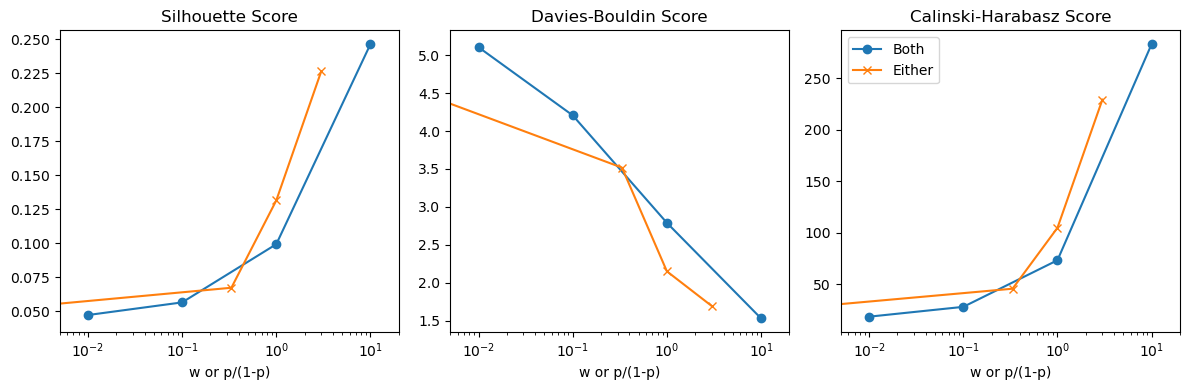

In [ ]:
cases_both = [0.01, 0.1, 1, 10]
cases_either = [0, 0.25, 0.5, 0.75]

# compute silhouette, davies bouldin, calinski harabasz for each case, make a plot as a function of the case values
silhouette_scores = np.zeros((2, 4))
davies_bouldin_scores = np.zeros((2, 4))
calinski_harabasz_scores = np.zeros((2, 4))
for i, case in enumerate(cases_both):
    tmp_test_proj = np.load(data_path%f"run_both_w{case}" + "test_projections.npy")
    tmp_test_labels = np.load(data_path%f"run_both_w{case}" + "test_labels.npy")
    # Mask for FRI only, FRII only, and hybrid
    mask_fri = (tmp_test_labels[:,0] == 1) & (tmp_test_labels[:,1] == 0) & (tmp_test_labels[:,2] == 0)
    mask_frii = (tmp_test_labels[:,0] == 0) & (tmp_test_labels[:,1] == 1) & (tmp_test_labels[:,2] == 0)
    mask_hybrid = tmp_test_labels[:, 2] == 1 #OK
    # Combine them
    combined_mask = mask_fri | mask_frii | mask_hybrid
    test_labels_single = np.argmax(tmp_test_labels[combined_mask], axis=1)
    silhouette_scores[0, i] = silhouette_score(tmp_test_proj[combined_mask], test_labels_single)
    davies_bouldin_scores[0, i] = davies_bouldin_score(tmp_test_proj[combined_mask], test_labels_single)
    calinski_harabasz_scores[0, i] = calinski_harabasz_score(tmp_test_proj[combined_mask], test_labels_single)

for i, case in enumerate(cases_either):
    tmp_test_proj = np.load(data_path%f"run_either_p{case}" + "test_projections.npy")
    tmp_test_labels = np.load(data_path%f"run_either_p{case}" + "test_labels.npy")
    # Mask for FRI only, FRII only, and hybrid
    mask_fri = (tmp_test_labels[:,0] == 1) & (tmp_test_labels[:,1] == 0) & (tmp_test_labels[:,2] == 0)
    mask_frii = (tmp_test_labels[:,0] == 0) & (tmp_test_labels[:,1] == 1) & (tmp_test_labels[:,2] == 0)
    mask_hybrid = tmp_test_labels[:, 2] == 1 #OK
    # Combine them
    combined_mask = mask_fri | mask_frii | mask_hybrid
    test_labels_single = np.argmax(tmp_test_labels[combined_mask], axis=1)
    silhouette_scores[1, i] = silhouette_score(tmp_test_proj[combined_mask], test_labels_single)
    davies_bouldin_scores[1, i] = davies_bouldin_score(tmp_test_proj[combined_mask], test_labels_single)
    calinski_harabasz_scores[1, i] = calinski_harabasz_score(tmp_test_proj[combined_mask], test_labels_single)

cases_both = np.array(cases_both)
cases_either = np.array(cases_either)
# Plot the scores
plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1)
plt.plot(cases_both, silhouette_scores[0], label='Both', marker='o')
plt.plot(cases_either/(1-cases_either)+1e-4, silhouette_scores[1], label='Either', marker='x')
plt.xlabel('w or p/(1-p)')
plt.title('Silhouette Score')
plt.xscale('log')
plt.xlim(0.005, 20)
plt.subplot(1, 3, 2)
plt.plot(cases_both, davies_bouldin_scores[0], label='Both', marker='o')
plt.plot(cases_either/(1-cases_either)+1e-4, davies_bouldin_scores[1], label='Either', marker='x')
plt.xlabel('w or p/(1-p)')
plt.title('Davies-Bouldin Score')
plt.xscale('log')
plt.xlim(0.005, 20)
plt.subplot(1, 3, 3)
plt.plot(cases_both, calinski_harabasz_scores[0], label='Both', marker='o')
plt.plot(cases_either/(1-cases_either)+1e-4, calinski_harabasz_scores[1], label='Either', marker='x')
plt.xlabel('w or p/(1-p)')
plt.title('Calinski-Harabasz Score')
plt.xscale('log')
plt.xlim(0.005, 20)
plt.legend()
plt.tight_layout()
plt.show()

Using outputs dir: /capstor/store/cscs/ska/sk030/projectG_supervised_latent_radiogals/outputs
both   | closest    | initial | [0.001, 0.01, 0.1, 0.3, 1.0, 3.0, 10.0, 100.0]
both   | closest    | full    | [0.001, 0.01, 0.1, 0.3, 1.0, 3.0, 10.0, 100.0]
both   | ponderate  | initial | [0.001, 0.01, 0.1, 0.3, 1.0, 3.0, 10.0, 100.0]
both   | ponderate  | full    | [0.001, 0.01, 0.1, 0.3, 1.0, 3.0, 10.0, 100.0]
either | ponderate  | full    | [0.0, 0.1, 0.25, 0.5, 0.75, 0.9, 0.95, 1.0]
either | ponderate  | initial | [0.0, 0.1, 0.25, 0.5, 0.75, 0.9, 0.95, 1.0]
either | closest    | full    | [0.0, 0.1, 0.25, 0.5, 0.75, 0.9, 0.95, 1.0]
either | closest    | initial | [0.0, 0.1, 0.25, 0.5, 0.75, 0.9, 0.95, 1.0]
5324 1142


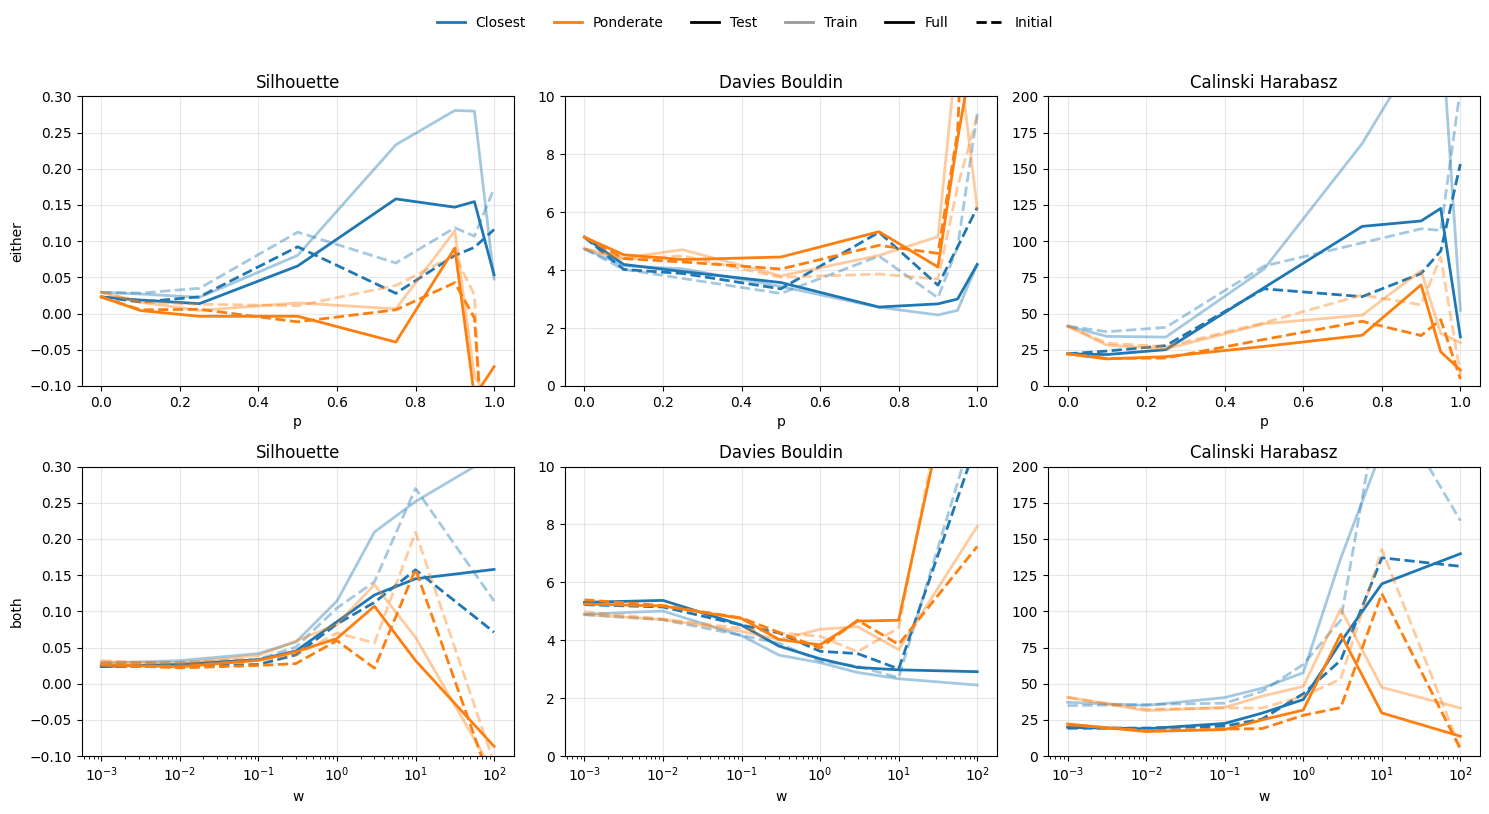

In [ ]:
import json
import re
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import json
import re
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

# -----------------------------------------------------------------------------
# Paths
# -----------------------------------------------------------------------------
cwd = Path.cwd()
if cwd.name == "notebooks":
    outputs_dir = cwd.parent / "outputs"
else:
    outputs_dir = cwd / "outputs"

print(f"Using outputs dir: {outputs_dir}")

# -----------------------------------------------------------------------------
# Parse folders
# -----------------------------------------------------------------------------
metrics_to_plot = ["silhouette", "davies_bouldin", "calinski_harabasz"]
dataset_key = "base_classes"

# We do NOT trust the "both/either" token in the folder name anymore.
# We infer:
#   - "_p..." => either
#   - "_w..." => both
pattern = re.compile(
    r"^run_(both|either)_(closest|ponderate)_(initial|full)_(w|p)([0-9.]+)_s\d+_.*$"
)

raw = {}

for folder in outputs_dir.iterdir():
    if not folder.is_dir():
        continue

    name = folder.name
    if ("initial" not in name) and ("full" not in name):
        continue

    m = pattern.match(name)
    if m is None:
        continue

    _, weighting, scope, param_kind, param_value = m.groups()
    param_value = float(param_value)

    # Infer the true supervision mode from parameter kind
    supervision = "either" if param_kind == "p" else "both"

    json_path = folder / "projection_metrics.json"
    if not json_path.exists():
        print(f"Missing json: {json_path}")
        continue

    with open(json_path, "r") as f:
        d = json.load(f)

    raw.setdefault(supervision, {}).setdefault(weighting, {}).setdefault(scope, [])

    raw[supervision][weighting][scope].append({
        "x": param_value,
        "train": {metric: d["train"][dataset_key][metric] for metric in metrics_to_plot},
        "test": {metric: d["test"][dataset_key][metric] for metric in metrics_to_plot},
        "folder": name,
    })

# Optional check
for supervision in raw:
    for weighting in raw[supervision]:
        for scope in raw[supervision][weighting]:
            xs = sorted(e["x"] for e in raw[supervision][weighting][scope])
            print(f"{supervision:6s} | {weighting:10s} | {scope:7s} | {xs}")

N_train = np.load('../outputs/run_both_closest_initial_p0.1_s97_20260323_1719/embeddings/train_projections.npy').shape[0]
N_test = np.load('../outputs/run_both_closest_initial_p0.1_s97_20260323_1719/embeddings/test_projections.npy').shape[0]
print(N_train, N_test)
# -----------------------------------------------------------------------------
# Plot
# -----------------------------------------------------------------------------
fig, axes = plt.subplots(2, 3, figsize=(15, 8), sharex=False)

row_map = {"either": 0, "both": 1}
col_map = {
    "silhouette": 0,
    "davies_bouldin": 1,
    "calinski_harabasz": 2,
}

color_map = {
    "closest": "C0",
    "ponderate": "C1",
}

alpha_map = {
    "train": 0.4,
    "test": 1.0,
}

linestyle_map = {
    "initial": "--",
    "full": "-",
}

ylim_map = {
    "silhouette": [-0.1, 0.3],
    "davies_bouldin": [0, 10],
    "calinski_harabasz": [0,200],
}
    

for supervision in ["either", "both"]:
    for metric in metrics_to_plot:
        ax = axes[row_map[supervision], col_map[metric]]

        for weighting in ["closest", "ponderate"]:
            for scope in ["initial", "full"]:
                entries = raw.get(supervision, {}).get(weighting, {}).get(scope, [])
                if len(entries) == 0:
                    continue

                entries = sorted(entries, key=lambda e: e["x"])
                x = np.array([e["x"] for e in entries])

                for split in ["train", "test"]:
                    y = np.array([e[split][metric] for e in entries])
                    if metric=='calinski_harabasz' and split=='train':
                        y = y *N_test/N_train

                    ax.plot(
                        x, y,
                        color=color_map[weighting],
                        alpha=alpha_map[split],
                        linestyle=linestyle_map[scope],
                        linewidth=2,
                    )

        ax.set_title(metric.replace("_", " ").title())
        ax.grid(True, alpha=0.3)
        ax.set_ylim(ylim_map[metric])
        if supervision == "both":
            ax.set_xscale("log")
            ax.set_xlabel("w")
        else:
            ax.set_xlabel("p")

        if col_map[metric] == 0:
            ax.set_ylabel(supervision)

# -----------------------------------------------------------------------------
# Custom legend (clean & readable)
# -----------------------------------------------------------------------------
from matplotlib.lines import Line2D

legend_elements = [
    Line2D([0], [0], color="C0", lw=2, label="Closest"),
    Line2D([0], [0], color="C1", lw=2, label="Ponderate"),
    Line2D([0], [0], color="black", lw=2, alpha=1.0, label="Test"),
    Line2D([0], [0], color="black", lw=2, alpha=0.4, label="Train"),
    Line2D([0], [0], color="black", lw=2, linestyle="-", label="Full"),
    Line2D([0], [0], color="black", lw=2, linestyle="--", label="Initial"),
]

fig.legend(
    handles=legend_elements,
    loc="upper center",
    ncol=6,
    frameon=False,
    bbox_to_anchor=(0.5, 1.02)
)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

In [ ]:
from pathlib import Path
import json, re
import numpy as np
import matplotlib.pyplot as plt

# ── USER CONFIG ──────────────────────────────────────────────────────────────
RUN_DIRS = [
    "/users/mbredber/p3_SUPLAT/outputs/GOOD_cond_base_20260402_1749",
    # add more directories here
]
# ─────────────────────────────────────────────────────────────────────────────

def extract_run_name(path):
    name = Path(path).name
    name = re.sub(r'^(GOOD_|INTERESTING_|run_)', '', name)
    name = re.sub(r'_\d{8}_\d{4}$', '', name)
    return name

METRICS   = ['silhouette', 'davies_bouldin', 'calinski_harabasz']
X_LABELS  = ['train\\nfri_vs_frii', 'train\\nbase_classes',
             'test\\nfri_vs_frii',  'test\\nbase_classes']
X_KEYS    = [('train','fri_vs_frii'), ('train','base_classes'),
             ('test','fri_vs_frii'),  ('test','base_classes')]

colors = plt.cm.tab10.colors
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Multi-run projection metrics comparison', fontsize=13)

for run_idx, run_dir in enumerate(RUN_DIRS):
    metrics_path = Path(run_dir) / 'projection_metrics.json'
    with open(metrics_path) as f:
        data = json.load(f)
    run_name = extract_run_name(run_dir)
    color = colors[run_idx % len(colors)]

    for ax, metric in zip(axes, METRICS):
        values = [data[split][grouping][metric] for split, grouping in X_KEYS]
        ax.plot(range(len(X_KEYS)), values, marker='o', label=run_name, color=color)

for ax, metric in zip(axes, METRICS):
    ax.set_title(metric.replace('_', ' ').title())
    ax.set_xticks(range(len(X_LABELS)))
    ax.set_xticklabels(X_LABELS, fontsize=9)
    ax.grid(True, alpha=0.3)

axes[0].legend(bbox_to_anchor=(0, -0.25), loc='upper left', ncol=3, fontsize=9)
fig.tight_layout()
plt.show()
